📌 Problem Statement

We want to build a system that can recognize handwritten digits (0–9).

The model will:

Learn from images of handwritten digits

Train using a Convolutional Neural Network (CNN)

Predict the digit in a test image

We will use the built-in MNIST dataset available in Keras.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: (60000, 28, 28)
Testing samples: (10000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 30ms/step - accuracy: 0.8948 - loss: 0.3382 - val_accuracy: 0.9864 - val_loss: 0.0395
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9845 - loss: 0.0497 - val_accuracy: 0.9873 - val_loss: 0.0371
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 74s 27ms/step - accuracy: 0.9909 - loss: 0.0319 - val_accuracy: 0.9896 - val_loss: 0.0317
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9867 - loss: 0.0388

Test Accuracy: 98.96 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


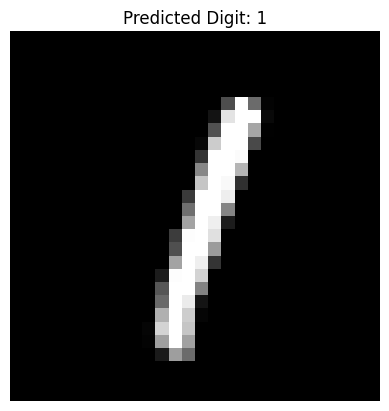

In [1]:
# ============================================
# Handwritten Digit Recognition using CNN
# Beginner Friendly
# Ready for Google Colab
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# -----------------------------------------
# Step 1: Load Dataset
# -----------------------------------------

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

# -----------------------------------------
# Step 2: Preprocess Data
# -----------------------------------------

# Normalize pixel values (0-255 → 0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN (add channel dimension)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# -----------------------------------------
# Step 3: Build CNN Model
# -----------------------------------------

model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

# -----------------------------------------
# Step 4: Compile Model
# -----------------------------------------

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# -----------------------------------------
# Step 5: Train Model
# -----------------------------------------

model.fit(X_train, y_train, epochs=3, validation_data=(X_test, y_test))

# -----------------------------------------
# Step 6: Evaluate Model
# -----------------------------------------

test_loss, test_acc = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", round(test_acc * 100, 2), "%")

# -----------------------------------------
# Step 7: Predict on a Sample Image
# -----------------------------------------

sample_index = 5
sample_image = X_test[sample_index]

prediction = model.predict(sample_image.reshape(1,28,28,1))
predicted_digit = np.argmax(prediction)

plt.imshow(sample_image.reshape(28,28), cmap='gray')
plt.title("Predicted Digit: " + str(predicted_digit))
plt.axis("off")
plt.show()